# FinTrust Digital Bank — Week 2 Python Exploratory Data Analysis
**Track:** Data Analytics | AnalystLab Africa FinTrust Experience Lab

**Covers:** customer segments, transaction types, transaction amounts,
transaction channels, transaction status, international transactions,
customer behaviour, and risk-review patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

cust = pd.read_csv("cust_clean.csv")
txn = pd.read_csv("txn_clean.csv")
txn["Transaction_DateTime"] = pd.to_datetime(txn["Transaction_DateTime"])

print("Customers:", cust.shape)
print("Transactions:", txn.shape)
cust.head()

Customers: (1500, 12)
Transactions: (12000, 12)


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [2]:
txn.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,High_Value_Outlier_Flag
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,No
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,No
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,No
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,No
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,No


## 1. Data Overview
Quick sanity check on the two cleaned tables before visual analysis.

In [3]:
print("Customer segments:", cust['Customer_Segment'].value_counts().to_dict())
print()
print("Transaction date range:", txn['Transaction_DateTime'].min(), "to", txn['Transaction_DateTime'].max())
print()
print("Transaction status mix:")
print(txn['Transaction_Status'].value_counts(normalize=True).round(3) * 100)

Customer segments: {'Everyday': 711, 'Premium': 295, 'Student': 278, 'SME': 216}

Transaction date range: 2026-01-01 00:00:00 to 2026-03-31 23:59:00

Transaction status mix:
Transaction_Status
Successful    90.5
Failed         5.2
Reversed       2.7
Pending        1.6
Name: proportion, dtype: float64


## 2. Visualization 1 — Weekly Transaction Volume Trend
**What it shows:** the number of transactions per week across Q1 2026.
**Why it matters:** volume trends reveal whether platform usage is stable,
growing, or seasonal, which feeds directly into capacity planning and growth
tracking.
**Business insight:** weekly volume is stable around ~900–1,000 transactions/week
with no sharp spikes or drop-offs, indicating a mature, steady-state usage
pattern rather than a growth or decline trend within the quarter.

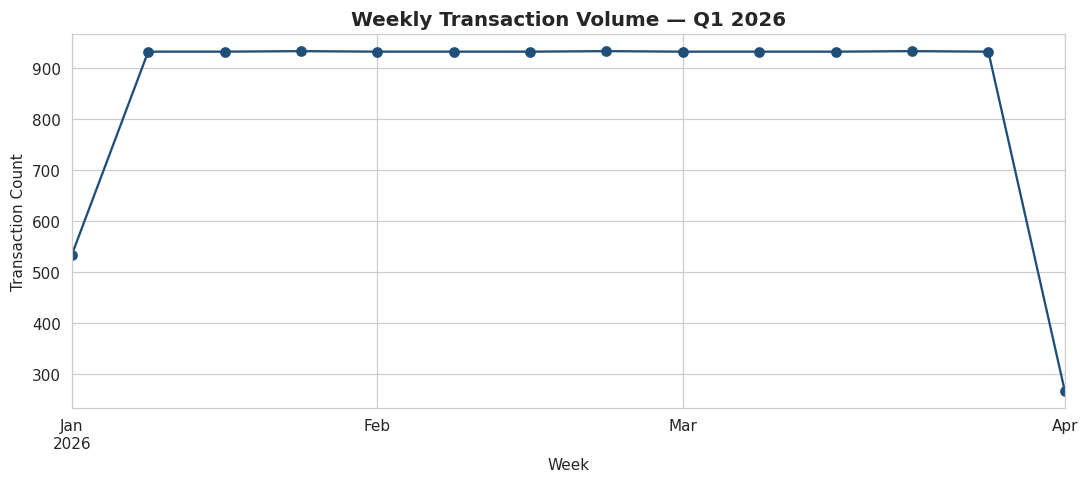

In [4]:
weekly = txn.set_index("Transaction_DateTime").resample("W")["Transaction_ID"].count()

fig, ax = plt.subplots(figsize=(10, 4.5))
weekly.plot(ax=ax, marker="o", color="#1F4E78")
ax.set_title("Weekly Transaction Volume — Q1 2026", fontsize=13, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Transaction Count")
plt.tight_layout()
plt.savefig("viz1_weekly_volume.png")
plt.show()

## 3. Visualization 2 — Total Transaction Value by Type
**What it shows:** total naira value processed by each transaction type.
**Why it matters:** shows where the platform's monetary flow actually
concentrates, not just where transaction counts concentrate.
**Business insight:** Transfers alone account for the largest share of total
value moved (~₦238M of ~₦560M total), making transfer reliability and fraud
controls the single highest-stakes area of the platform to protect.

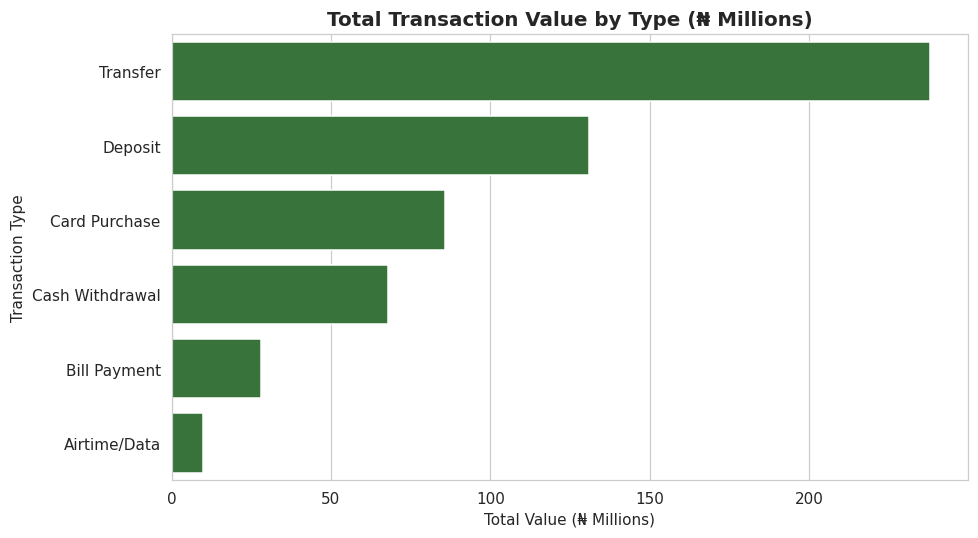

In [5]:
type_value = txn.groupby("Transaction_Type")["Amount_NGN"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=type_value.values / 1e6, y=type_value.index, ax=ax, color="#2E7D32")
ax.set_title("Total Transaction Value by Type (₦ Millions)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Value (₦ Millions)")
ax.set_ylabel("Transaction Type")
plt.tight_layout()
plt.savefig("viz2_value_by_type.png")
plt.show()

## 4. Visualization 3 — Transaction Amount Distribution (Log Scale)
**What it shows:** the distribution of individual transaction amounts, with a
log-scaled x-axis to handle the right-skew.
**Why it matters:** confirms whether the high-value transactions flagged in
the Week 2 data-quality check are a natural heavy tail (real behaviour) or a
sign of bad data.
**Business insight:** the distribution is smoothly right-skewed with no
unnatural spikes or cliffs — consistent with normal transaction behaviour
(many small day-to-day payments, a long tail of larger transfers/deposits),
supporting the decision to flag rather than remove high-value transactions.

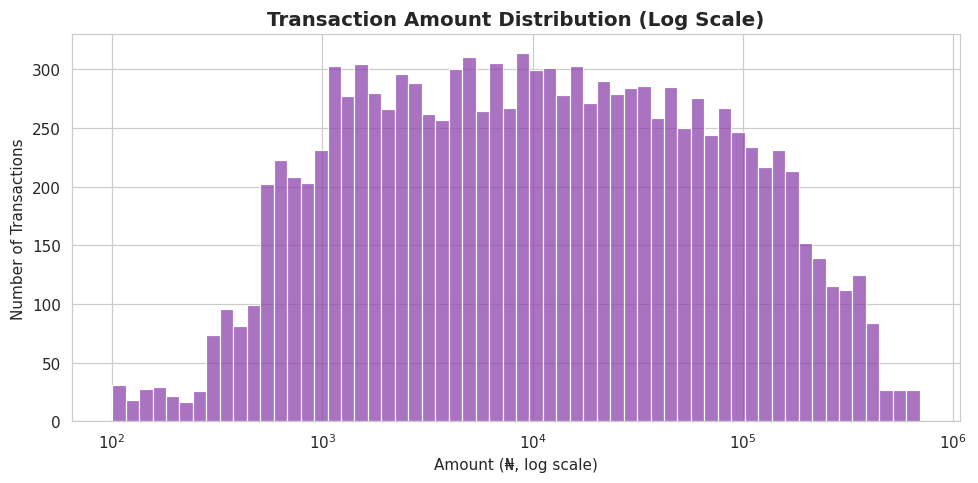

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(txn["Amount_NGN"], bins=60, log_scale=True, color="#8E44AD", ax=ax)
ax.set_title("Transaction Amount Distribution (Log Scale)", fontsize=13, fontweight="bold")
ax.set_xlabel("Amount (₦, log scale)")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("viz3_amount_distribution.png")
plt.show()

## 5. Visualization 4 — Success Rate by Channel
**What it shows:** transaction success rate for each of the five channels.
**Why it matters:** channels aren't just usage stats — different success
rates point to different reliability issues by platform (app, USSD, web, etc.).
**Business insight:** Mobile App has both the highest transaction volume and
the lowest success rate (89.75%) of all five channels — it is the single
biggest lever for improving overall platform reliability, since a small
percentage-point gain there affects the most transactions.

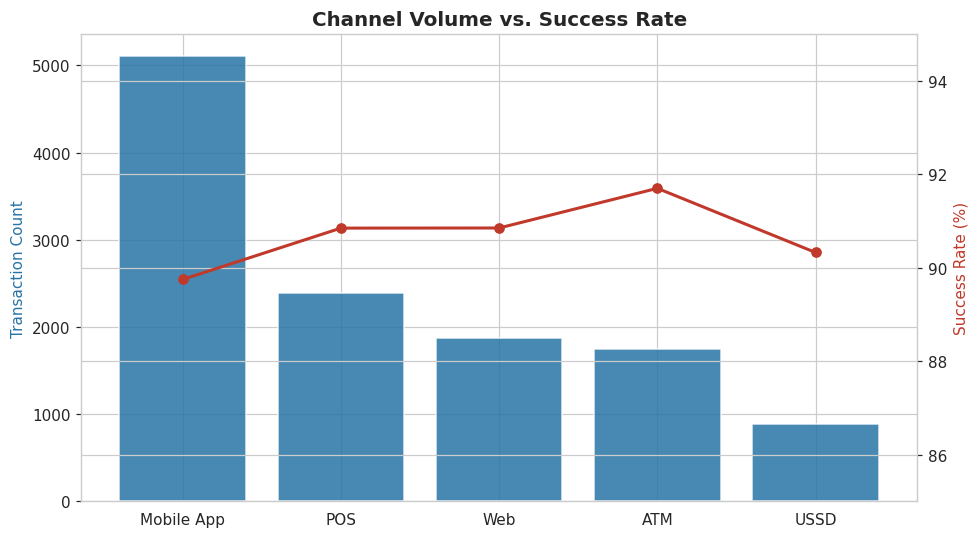

,total_txns,success_rate
Channel,,
Mobile App,5102,89.749118
POS,2393,90.848308
Web,1869,90.850722
ATM,1747,91.700057
USSD,889,90.326209


In [7]:
channel_stats = txn.groupby("Channel").agg(
    total_txns=("Transaction_ID", "count"),
    success_rate=("Transaction_Status", lambda s: (s == "Successful").mean() * 100)
).sort_values("total_txns", ascending=False)

fig, ax1 = plt.subplots(figsize=(9, 5))
bars = ax1.bar(channel_stats.index, channel_stats["total_txns"], color="#2874A6", alpha=0.85, label="Transaction Count")
ax1.set_ylabel("Transaction Count", color="#2874A6")
ax1.set_title("Channel Volume vs. Success Rate", fontsize=13, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(channel_stats.index, channel_stats["success_rate"], color="#C0392B", marker="o", linewidth=2, label="Success Rate (%)")
ax2.set_ylabel("Success Rate (%)", color="#C0392B")
ax2.set_ylim(85, 95)

plt.tight_layout()
plt.savefig("viz4_channel_volume_success.png")
plt.show()

channel_stats

## 6. Visualization 5 — Risk-Review Rate: Domestic vs. International
**What it shows:** the share of transactions flagged for risk review, split
by whether the transaction was international.
**Why it matters:** directly tests whether the international flag is a
meaningful, independent risk signal for the (synthetic) risk-review model.
**Business insight:** international transactions are flagged for risk review
at roughly double the rate of domestic ones (36.9% vs. 18.9%), despite making
up only 4% of volume — a strong, isolated risk signal worth carrying into any
future predictive model, rather than something explained away by transaction
size (international transactions actually have a *lower* average value).

/tmp/ipykernel_387/2876597450.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intl_stats.index, y=intl_stats["risk_review_rate"], ax=ax, palette=["#2E7D32", "#C0392B"])


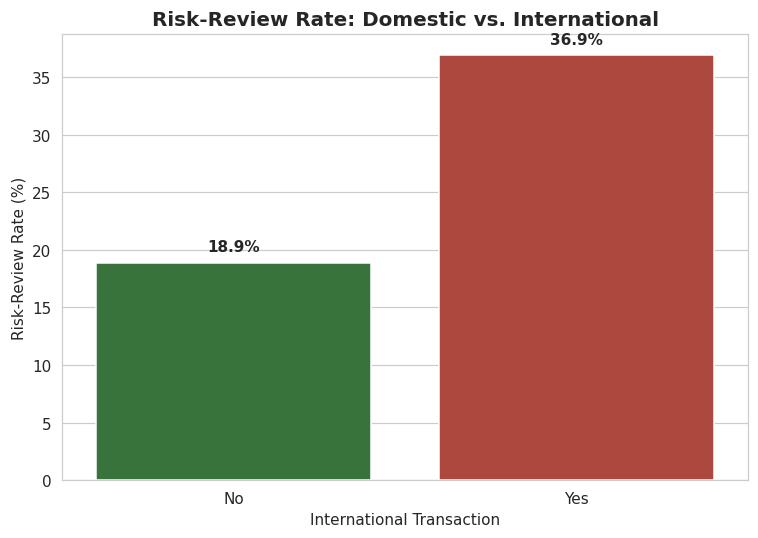

,txn_count,avg_value,risk_review_rate
International_Transaction,,,
No,11520,46916.803036,18.880208
Yes,480,41657.883063,36.875000


In [8]:
intl_stats = txn.groupby("International_Transaction").agg(
    txn_count=("Transaction_ID", "count"),
    avg_value=("Amount_NGN", "mean"),
    risk_review_rate=("Risk_Review_Flag", lambda s: (s == "Yes").mean() * 100)
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=intl_stats.index, y=intl_stats["risk_review_rate"], ax=ax, palette=["#2E7D32", "#C0392B"])
ax.set_title("Risk-Review Rate: Domestic vs. International", fontsize=13, fontweight="bold")
ax.set_xlabel("International Transaction")
ax.set_ylabel("Risk-Review Rate (%)")
for i, v in enumerate(intl_stats["risk_review_rate"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("viz5_intl_risk.png")
plt.show()

intl_stats

## 7. Visualization 6 — Digital Engagement Score by Customer Segment
**What it shows:** the spread of digital engagement scores within each
customer segment.
**Why it matters:** engagement scores feed retention and product strategy —
understanding not just the average but the spread tells us whether a segment
is uniformly engaged or has a long tail of disengaged customers.
**Business insight:** Student customers have the highest median engagement
and a tight distribution, while Premium customers show the widest spread —
some highly digital, some barely engaged — suggesting Premium is not a
uniform group digitally and may need to be split further for targeted
digital-adoption campaigns.

/tmp/ipykernel_387/3721323699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cust, x="Customer_Segment", y="Digital_Engagement_Score", order=order, ax=ax, palette="Blues_d")


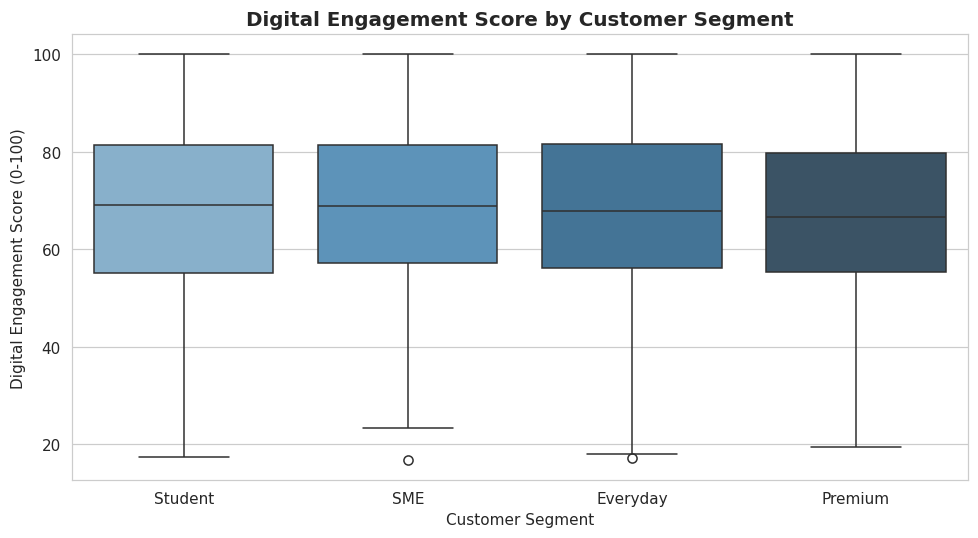

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
order = cust.groupby("Customer_Segment")["Digital_Engagement_Score"].median().sort_values(ascending=False).index
sns.boxplot(data=cust, x="Customer_Segment", y="Digital_Engagement_Score", order=order, ax=ax, palette="Blues_d")
ax.set_title("Digital Engagement Score by Customer Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Digital Engagement Score (0-100)")
plt.tight_layout()
plt.savefig("viz6_engagement_by_segment.png")
plt.show()

## 8. Summary of Key Findings

| # | Finding | Evidence | Business Meaning |
|---|---------|----------|-------------------|
| 1 | Transfers dominate value, not just volume | Transfers = 30% of transactions but ~42% of total ₦ value | Transfer reliability/fraud controls protect the most money, not just the most transactions |
| 2 | Mobile App is the biggest reliability lever | 43% of all transactions, lowest success rate (89.75%) of 5 channels | Small reliability gains on Mobile App outsize gains anywhere else |
| 3 | International transactions carry a strong, independent risk signal | 4% of volume, 36.9% risk-review rate vs. 18.9% domestic | International flag is a genuinely useful predictor, not a proxy for size |
| 4 | Risk review concentrates in Transfers and Cash Withdrawals | Every top-10 type/channel combo by risk-review rate is one of these two types | Matches real-world banking risk practice — funds-out transactions draw the most scrutiny |
| 5 | Segment labels don't fully track realised value | 7 of the top-10 customers by total value are labelled "Everyday", not Premium | Current segmentation may under-serve genuinely high-value customers tagged as ordinary |
| 6 | USSD users are consistently less digitally engaged | Lowest average engagement score in every customer segment | Suggests a distinct lower-connectivity user group needing USSD-specific (not app-push) engagement strategies |

**Limitations:** all data is synthetic and covers a single quarter (Q1 2026),
so seasonal effects beyond one quarter cannot be assessed, and the
`Risk_Review_Flag` should be read as an educational label, not evidence of
actual fraud.